<a href="https://colab.research.google.com/github/Zeldian-Soul/AI-ML-lab-/blob/main/A_star.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Least cost path from A to G: A -> C -> E -> G
Total cost: 7


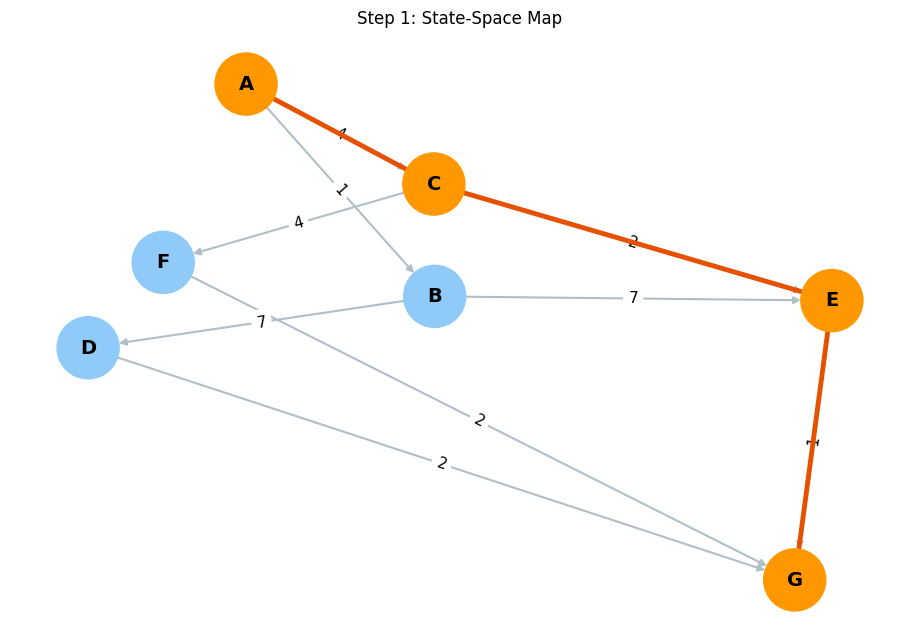

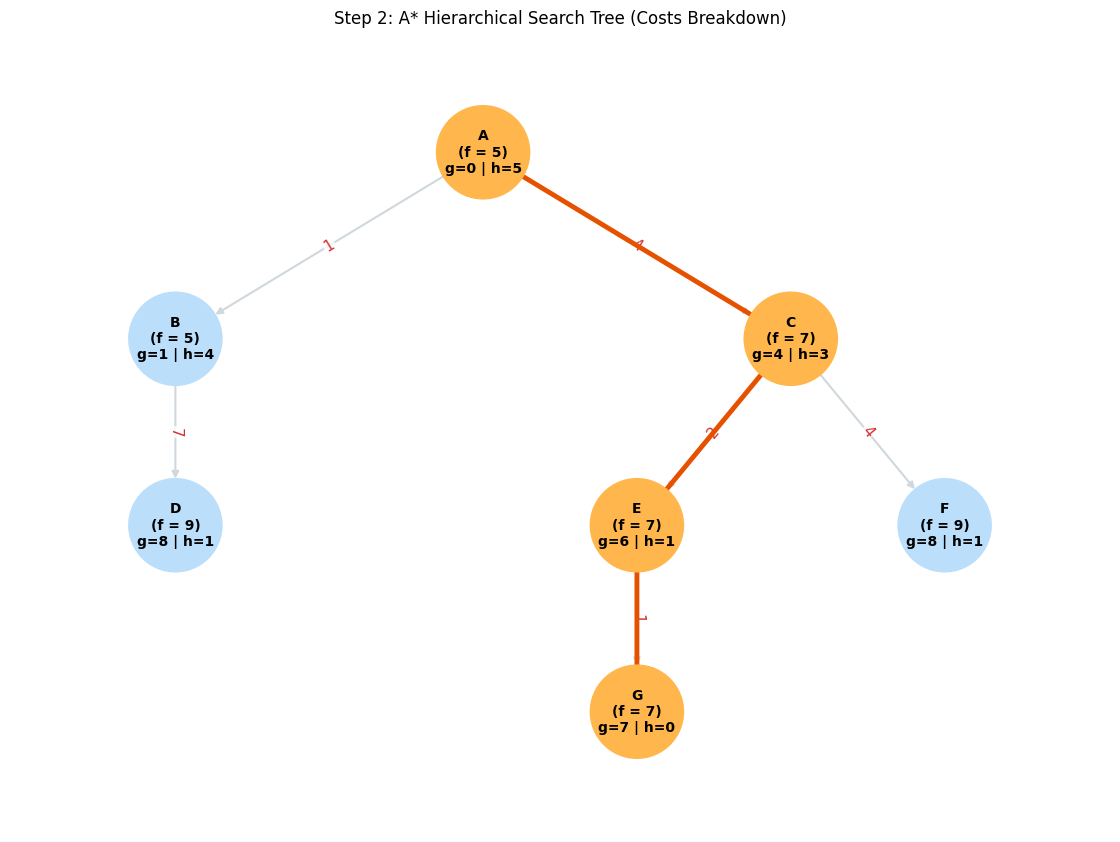

In [28]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def a_star_search(graph, heuristics, start, goal):
    priority_queue = [(heuristics[start], 0, start)]
    visited = {start: (0, None)}
    node_stats = {start: {'g': 0, 'h': heuristics[start], 'f': heuristics[start]}}

    while priority_queue:
        current_f, current_g, current_node = heapq.heappop(priority_queue)

        if current_node == goal:
            path = reconstruct_path(visited, start, goal)
            return current_g, path, visited, node_stats

        for neighbor, move_cost in graph.get(current_node, []):
            tentative_g = current_g + move_cost

            if neighbor not in visited or tentative_g < visited[neighbor][0]:
                visited[neighbor] = (tentative_g, current_node)

                h = heuristics.get(neighbor, 0)
                f_score = tentative_g + h

                node_stats[neighbor] = {'g': tentative_g, 'h': h, 'f': f_score}

                heapq.heappush(priority_queue, (f_score, tentative_g, neighbor))

    return None, None, visited, node_stats

def reconstruct_path(visited, start, goal):
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = visited[current][1]
    path.reverse()
    return path

def visualize_graph(graph, path=None):
    G = nx.DiGraph()
    for node, edges in graph.items():
        for neighbor, cost in edges:
            G.add_edge(node, neighbor, weight=cost)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(9, 6))

    # Modern color palette for Map
    node_colors = ['#FF9800' if path and n in path else '#90CAF9' for n in G.nodes]

    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000,
            font_size=14, font_weight='bold', edge_color='#B0BEC5', arrows=True, width=1.5)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=11)

    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#E65100', width=3.5, arrows=True)

    plt.title("Step 1: State-Space Map")
    plt.axis('off')
    plt.show()

def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
    if pos is None:
        pos = {root: (xcenter, vert_loc)}
    else:
        pos[root] = (xcenter, vert_loc)

    neighbors = list(G.neighbors(root))
    if parent is not None and parent in neighbors:
        neighbors.remove(parent)

    if len(neighbors) != 0:
        dx = width / len(neighbors)
        nextx = xcenter - width/2 - dx/2
        for neighbor in neighbors:
            nextx += dx
            pos = hierarchy_pos(G, neighbor, width=dx, vert_gap=vert_gap,
                                vert_loc=vert_loc-vert_gap, xcenter=nextx, pos=pos, parent=root)
    return pos

def visualize_search_tree(visited, node_stats, path, start, original_graph):
    T = nx.DiGraph()
    T.add_node(start)

    # Construct the tree and extract edge weights from the original graph
    for node, (cost, parent) in visited.items():
        if parent is not None:
            # Find the exact step cost from parent to this node
            step_cost = next((weight for neighbor, weight in original_graph[parent] if neighbor == node), 0)
            T.add_edge(parent, node, weight=step_cost)

    pos = hierarchy_pos(T, root=start, width=2.5, vert_gap=0.3)

    # Detailed multiline labels inside nodes
    labels = {}
    for n in T.nodes:
        stats = node_stats[n]
        labels[n] = f"{n}\n(f = {stats['f']})\ng={stats['g']} | h={stats['h']}"

    plt.figure(figsize=(11, 8))

    path_nodes = set(path) if path else set()

    # Better colors: Vibrant Orange for optimal path, Soft Blue for explored dead-ends
    node_colors = ['#FFB74D' if n in path_nodes else '#BBDEFB' for n in T.nodes]

    # Draw nodes
    nx.draw(T, pos, with_labels=False, node_color=node_colors, node_size=4500,
            edge_color='#CFD8DC', arrows=True, node_shape='o', width=1.5)

    # Draw node labels
    nx.draw_networkx_labels(T, pos, labels, font_size=10, font_family='sans-serif', font_weight='bold')

    # Draw edge weights (step costs) on the tree branches
    edge_labels = nx.get_edge_attributes(T, 'weight')
    nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels, font_size=11, font_color='#D32F2F',
                                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

    # Highlight optimal path branches
    if path:
        path_edges = list(zip(path, path[1:]))
        tree_path_edges = [edge for edge in path_edges if T.has_edge(*edge)]
        nx.draw_networkx_edges(T, pos, edgelist=tree_path_edges, edge_color='#E65100', width=3.5, arrows=True)

    plt.title("Step 2: A* Hierarchical Search Tree (Costs Breakdown)")
    plt.axis('off')
    plt.margins(0.15)
    plt.show()


# Example graph represented as an adjacency list
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 7), ('E', 7)],
    'C': [('F', 4), ('E', 2)],
    'D': [('G', 2)],
    'E': [('G', 1)],
    'F': [('G', 2)],
    'G': []
}

heuristics = {
    'A': 5,
    'B': 4,
    'C': 3,
    'D': 1,
    'E': 1,
    'F': 1,
    'G': 0
}

def main():
    start_node = 'A'
    goal_node = 'G'

    result = a_star_search(graph, heuristics, start_node, goal_node)

    if result[0] is not None:
        total_cost, path, visited, node_stats = result
        print(f"Least cost path from {start_node} to {goal_node}: {' -> '.join(path)}")
        print(f"Total cost: {total_cost}")

        # 1. Visualize geographic graph
        visualize_graph(graph, path)

        # 2. Visualize decision tree (pass the original graph to extract edge weights)
        visualize_search_tree(visited, node_stats, path, start_node, graph)
    else:
        print(f"No path found from {start_node} to {goal_node}")

if __name__ == "__main__":
    main()